# Caso Contínuo — Retornos Financeiros
## A Lei dos Grandes Números: média amostral $\to$ esperança (devagar e com ruído)

**Trabalho de Probabilidade — Aplicações da Lei dos Grandes Números (LGN)**

Este é o segundo estudo de caso. No primeiro notebook usamos a Mega-Sena, um fenômeno
**discreto** com alvos **conhecidos a priori** ($p=0{,}10$, $\mu=30{,}5$), e vimos a
LGN convergir de forma limpa. Aqui invertemos quase tudo:

| | Caso discreto (Mega-Sena) | Caso contínuo (retornos) |
|---|---|---|
| Natureza | discreta | **contínua** |
| Alvo $\mu$ | **conhecido** por construção | **estimado** dos próprios dados |
| Variância relativa | moderada (CV $\approx 0{,}57$) | **enorme** (CV $\approx 18$) |
| Convergência | rápida e limpa | **lenta e ruidosa** |

O objetivo é mostrar que a **LGN continua válida** — a média acumulada dos retornos
*converge* para a média populacional — mas a **velocidade** é dramaticamente menor,
porque o erro padrão $\sigma/\sqrt{n}$ é dominado por um $\sigma$ gigantesco frente a
um $\mu$ minúsculo. Esse contraste de *velocidade* (não de *validade*) é o argumento
central do trabalho.

> Os dados foram gerados pelo script `scripts/gerar_retornos.py`, que baixa via
> `yfinance` o histórico de preços ajustados de um ativo (default **PETR4.SA**, ~10
> anos) e calcula os retornos diários. Veja a seção 2.


---
## 1. Fundamentação teórica (revisão dirigida ao caso contínuo)

Seja $R_1, R_2, \dots, R_n$ os retornos diários, vistos como variáveis aleatórias com

$$\mathbb{E}[R_i] = \mu, \qquad \operatorname{Var}(R_i) = \sigma^2.$$

A **média amostral** $\bar{R}_n = \frac{1}{n}\sum_{i=1}^n R_i$ satisfaz, pela LGN,

$$\bar{R}_n \xrightarrow{\;n\to\infty\;} \mu.$$

### 1.1 A velocidade é governada por $\sigma/\sqrt{n}$

Como antes, $\operatorname{Var}(\bar{R}_n) = \sigma^2/n$, logo o erro padrão é
$\sigma/\sqrt{n}$. O ponto novo deste caso é olhar o **erro relativo** da estimativa,
isto é, o erro padrão em unidades da própria média:

$$\frac{\operatorname{EP}(\bar{R}_n)}{|\mu|}
= \frac{\sigma/\sqrt{n}}{|\mu|}
= \frac{\text{CV}}{\sqrt{n}},
\qquad \text{onde } \text{CV} = \frac{\sigma}{|\mu|}.$$

O **coeficiente de variação** (CV) é quem manda na velocidade:

- **Mega-Sena:** $\text{CV} = 17{,}3/30{,}5 \approx 0{,}57$.
- **Retornos:** $\text{CV} \approx 18$ — cerca de **30 vezes maior**.

Para atingir um erro relativo de $10\%$ ($\text{CV}/\sqrt{n} = 0{,}1$) precisamos de

$$n = \left(\frac{\text{CV}}{0{,}1}\right)^2.$$

Na loteria isso dá $n \approx 32$ observações. Nos retornos dá $n \approx 32.000$ dias
— **mais de um século** de pregões. É a LGN dizendo: *eu valho, mas vou demorar.*

### 1.2 Alvo conhecido vs. estimado

Diferença conceitual importante em relação ao notebook 1: aqui **não conhecemos**
$\mu$ de antemão. Tratamos a série inteira como "população" e usamos sua média como
**estimativa** $\hat{\mu}$ do alvo. Consequência honesta: a média acumulada, ao chegar
no último ponto ($n = N$), coincide *por construção* com $\hat{\mu}$. O que demonstra a
LGN não é o ponto final, e sim o **caminho** percorrido — quão tarde a curva entra e
permanece numa vizinhança estreita do alvo.


---
## 2. Apresentação dos dados

O arquivo `data/retornos.csv` foi produzido por `scripts/gerar_retornos.py`. Para cada
dia de pregão ele traz:

- `Data` — data do pregão (`AAAA-MM-DD`);
- `Fechamento` — preço de fechamento **ajustado** (proventos/desdobramentos);
- `retorno_simples` — variação percentual diária, $R_t = \dfrac{P_t}{P_{t-1}} - 1$;
- `retorno_log` — retorno logarítmico, $r_t = \ln\!\big(P_t / P_{t-1}\big)$.

O retorno do primeiro dia não existe (não há dia anterior) e já foi removido na
geração. Carregamos e inspecionamos:


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (11, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
})

CAMINHO = "../data/retornos.csv"
ret = pd.read_csv(CAMINHO, parse_dates=["Data"])

print("Formato (linhas, colunas):", ret.shape)
print("Período:", ret["Data"].min().date(), "a", ret["Data"].max().date())
ret.head()

Formato (linhas, colunas): (2490, 4)
Período: 2016-06-30 a 2026-06-29


,Data,Fechamento,retorno_simples,retorno_log
0,2016-06-30,2.433883,-0.008421,-0.008456
1,2016-07-01,2.537232,0.042463,0.041586
2,2016-07-04,2.550150,0.005092,0.005079
3,2016-07-05,2.400294,-0.058764,-0.060561
4,2016-07-06,2.454552,0.022605,0.022353


### 2.1 Por que retornos, e não preços?

A LGN exige variáveis com a *mesma* distribuição (i.i.d. é o ideal). **Preços** não
servem: eles têm tendência, não são estacionários, e sua "média" não tem significado
de esperança fixa. Já os **retornos** são aproximadamente estacionários e oscilam em
torno de uma média pequena — é sobre eles que faz sentido aplicar a LGN.

Usaremos o **retorno simples** como variável principal (o `retorno_log` fica como
alternativa; para valores pequenos $r_t \approx R_t$).


---
## 3. Limpeza e verificações de sanidade

O CSV já sai limpo do script gerador, mas em análise de dados nunca confiamos às
cegas. Conferimos: ausência de `NaN`, ordenação temporal, e a magnitude dos retornos
(devem ser números pequenos, da ordem de poucos por cento ao dia).


In [2]:
# 1) Sem valores ausentes?
print("Valores ausentes por coluna:")
print(ret.isna().sum(), "\n")

# 2) Datas em ordem crescente?
print("Datas ordenadas?", ret["Data"].is_monotonic_increasing)

# 3) Garantir ordem cronológica (a LGN acumula na ordem do tempo).
ret = ret.sort_values("Data").reset_index(drop=True)

# 4) Magnitude plausível dos retornos simples
R = ret["retorno_simples"].to_numpy()
print(f"\nRetorno simples — min: {R.min():.4f}  max: {R.max():.4f}")
print(f"Maior queda diária: {R.min()*100:.2f}%   |   maior alta diária: {R.max()*100:.2f}%")
print(f"Nº de observações (dias): {len(R)}")

Valores ausentes por coluna:
Data               0
Fechamento         0
retorno_simples    0
retorno_log        0
dtype: int64 

Datas ordenadas? True

Retorno simples — min: -0.2970  max: 0.2222
Maior queda diária: -29.70%   |   maior alta diária: 22.22%
Nº de observações (dias): 2490


Os extremos (quedas e altas de vários por cento num único dia) já anunciam a
**alta volatilidade** que vai tornar a convergência lenta. Compare com a loteria, onde
cada observação era um inteiro entre 1 e 60, de variação controlada.


In [3]:
# Estatísticas-resumo que fundamentam o argumento de velocidade.
mu = R.mean()                 # estimativa do alvo (média populacional)
sigma = R.std(ddof=1)         # desvio padrão amostral
cv = sigma / abs(mu)          # coeficiente de variação

print(f"Média do retorno diário (mu_hat) : {mu:.6f}   ({mu*100:.4f}% ao dia)")
print(f"Desvio padrão (sigma)            : {sigma:.6f}   ({sigma*100:.4f}% ao dia)")
print(f"Coeficiente de variação (sigma/|mu|): {cv:.1f}x")
print()
# Quantos dias para erro relativo de 10%?  n = (CV/0.1)^2
n_10pct = (cv / 0.10) ** 2
print(f"Dias necessários p/ erro relativo de 10%: {n_10pct:,.0f}")
print(f"  ... equivalente a ~{n_10pct/252:,.0f} anos de pregão (252 dias/ano)")

Média do retorno diário (mu_hat) : 0.001445   (0.1445% ao dia)
Desvio padrão (sigma)            : 0.025872   (2.5872% ao dia)
Coeficiente de variação (sigma/|mu|): 17.9x

Dias necessários p/ erro relativo de 10%: 32,070
  ... equivalente a ~127 anos de pregão (252 dias/ano)


**Esse é o número que define o trabalho.** Um coeficiente de variação na casa de
$18\times$ significa que o ruído de um único dia é dezenas de vezes maior que o sinal
(a média). Para estimar a média diária com apenas $10\%$ de erro relativo seriam
necessários **dezenas de milhares de pregões** — mais de um século. A LGN garante que
chegaríamos lá; ela só não promete que seja rápido.


---
## 4. A cara dos dados — a série de retornos

Antes de acumular, vejamos a série diária. Procuramos duas coisas: (i) a oscilação em
torno de uma média quase nula e (ii) os "agrupamentos" de volatilidade (períodos
calmos e períodos turbulentos), que serão importantes na discussão da hipótese i.i.d.


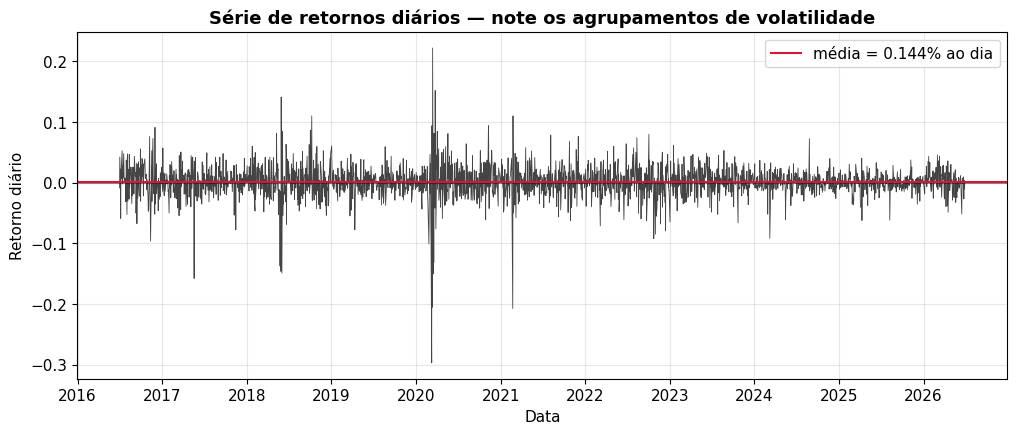

In [4]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(ret["Data"], R, lw=0.6, color="#444")
ax.axhline(mu, color="crimson", lw=1.5, label=f"média = {mu*100:.3f}% ao dia")
ax.axhline(0, color="black", lw=0.8, alpha=0.4)
ax.set_xlabel("Data")
ax.set_ylabel("Retorno diário")
ax.set_title("Série de retornos diários — note os agrupamentos de volatilidade")
ax.legend()
plt.show()

**Lendo o gráfico.** A linha vermelha (a média) é praticamente indistinguível do
zero diante da amplitude das oscilações diárias — uma imagem direta de "sinal minúsculo,
ruído enorme". Observe também que a turbulência **vem em ondas**: dias agitados tendem a
ser seguidos de dias agitados (*volatility clustering*). Isso viola a hipótese de
distribuição idêntica/independente e será discutido na seção 7.


---
## 5. Demonstração — média acumulada $\to$ esperança

Construímos a média acumulada

$$\bar{R}_n = \frac{1}{n}\sum_{t=1}^{n} R_t$$

e a comparamos com a estimativa do alvo $\hat{\mu}$ (a média da série completa).


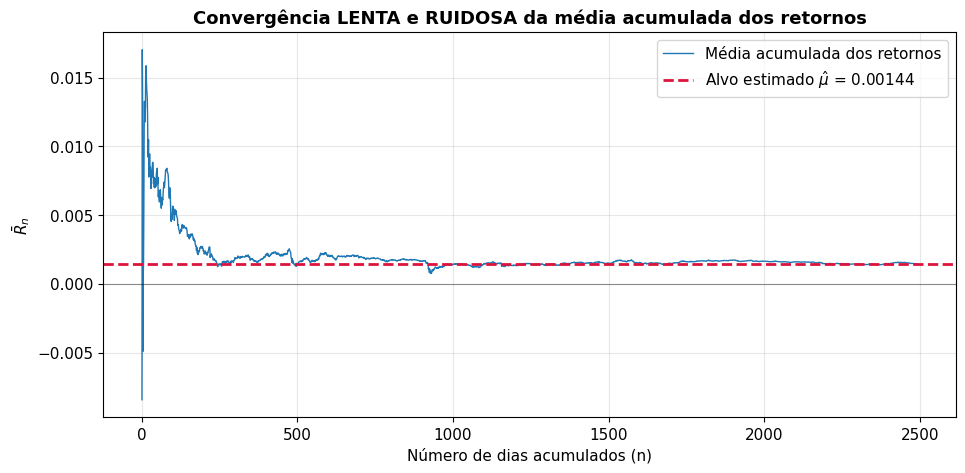

In [5]:
n_eixo = np.arange(1, len(R) + 1)
media_acum = np.cumsum(R) / n_eixo

fig, ax = plt.subplots()
ax.plot(n_eixo, media_acum, lw=1.0, color="#1f77b4", label="Média acumulada dos retornos")
ax.axhline(mu, color="crimson", ls="--", lw=2, label=f"Alvo estimado $\\hat\\mu$ = {mu:.5f}")
ax.axhline(0, color="black", lw=0.8, alpha=0.4)
ax.set_xlabel("Número de dias acumulados (n)")
ax.set_ylabel(r"$\bar{R}_n$")
ax.set_title("Convergência LENTA e RUIDOSA da média acumulada dos retornos")
ax.legend()
plt.show()

**Lendo o gráfico.** Compare mentalmente com a curva limpíssima da Mega-Sena.
Aqui a média acumulada:

- passa **muito tempo longe** do alvo, inclusive ficando **negativa** por longos
  trechos (a ação "andou de lado ou caiu" por anos);
- só se aproxima de $\hat{\mu}$ bem perto do fim da série;
- termina exatamente sobre $\hat{\mu}$ — mas isso é **artefato de construção** (o alvo
  é a média de toda a série), não a prova da convergência. A prova é *qualitativa*: as
  oscilações **diminuem** conforme $n$ cresce, exatamente como prevê a LGN, só que num
  ritmo arrastado.

A diferença visual entre este gráfico e o da loteria é, em uma imagem, a tese do
trabalho: **mesma lei, velocidades opostas.**


### 5.1 A faixa teórica $\hat\mu \pm 2\,\sigma/\sqrt{n}$

Sobrepomos a faixa de $\pm 2$ erros padrão. Por causa do $\sigma$ enorme, a faixa é
**larguíssima** para $n$ pequeno e afunila devagar — visualmente o oposto do funil
apertado da loteria.


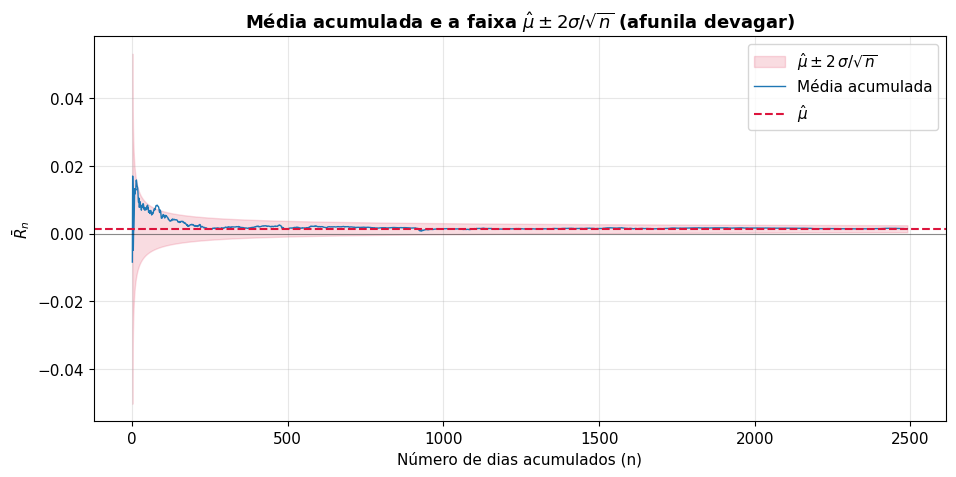

In [6]:
ep = sigma / np.sqrt(n_eixo)
sup, inf = mu + 2*ep, mu - 2*ep

fig, ax = plt.subplots()
ax.fill_between(n_eixo, inf, sup, color="crimson", alpha=0.15,
                label=r"$\hat\mu \pm 2\,\sigma/\sqrt{n}$")
ax.plot(n_eixo, media_acum, lw=1.0, color="#1f77b4", label="Média acumulada")
ax.axhline(mu, color="crimson", ls="--", lw=1.5, label=r"$\hat\mu$")
ax.axhline(0, color="black", lw=0.8, alpha=0.4)
ax.set_xlabel("Número de dias acumulados (n)")
ax.set_ylabel(r"$\bar{R}_n$")
ax.set_title(r"Média acumulada e a faixa $\hat\mu \pm 2\sigma/\sqrt{n}$ (afunila devagar)")
ax.legend()
plt.show()

**Lendo o gráfico.** A faixa começa enorme — em $n=1$ ela tem largura de vários
pontos percentuais — e encolhe como $1/\sqrt{n}$, mas mesmo no fim da série ela ainda
**inclui o zero** com folga. Tradução prática: com ~10 anos de dados ainda **não
conseguimos afirmar com segurança** que a média diária é diferente de zero. É a
manifestação concreta da convergência lenta.


---
## 6. A variância da média encolhe: $\operatorname{Var}(\bar{R}_n) = \sigma^2/n$

A demonstração acima acompanha **uma única** trajetória. Para enxergar a LGN de forma
estatística, fazemos um experimento de **reamostragem**: para vários tamanhos $n$,
sorteamos muitas amostras de tamanho $n$ (com reposição, *bootstrap*) e olhamos a
**distribuição das médias amostrais**. A LGN prevê que essa distribuição se concentre
em torno de $\mu$, com dispersão caindo como $\sigma/\sqrt{n}$.


In [7]:
rng = np.random.default_rng(42)
tamanhos = [10, 50, 250, 1000]   # ~2 semanas, ~2 meses, ~1 ano, ~4 anos
B = 3000                          # nº de amostras por tamanho

medias_por_n = {}
print(f"{'n':>6} | {'desvio empírico':>16} | {'sigma/sqrt(n) teórico':>22}")
print("-" * 50)
for n in tamanhos:
    amostras = rng.choice(R, size=(B, n), replace=True)
    medias = amostras.mean(axis=1)
    medias_por_n[n] = medias
    print(f"{n:>6} | {medias.std():>16.6f} | {sigma/np.sqrt(n):>22.6f}")

     n |  desvio empírico |  sigma/sqrt(n) teórico
--------------------------------------------------
    10 |         0.008237 |               0.008181
    50 |         0.003725 |               0.003659
   250 |         0.001638 |               0.001636
  1000 |         0.000819 |               0.000818


A tabela confirma a teoria: o **desvio empírico** das médias amostrais bate com o
**$\sigma/\sqrt{n}$ teórico**. Cada vez que $n$ cresce $4\times$, a dispersão cai pela
metade. Visualizamos com histogramas sobrepostos:


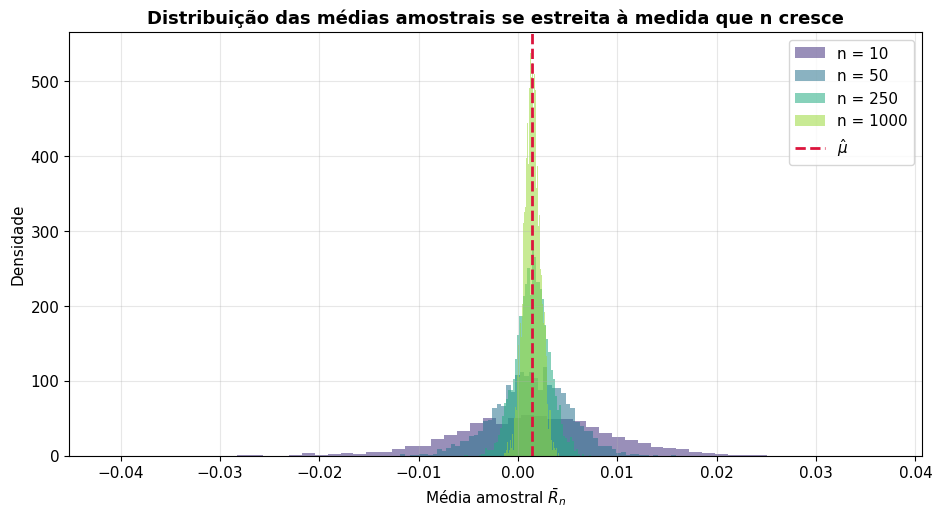

In [8]:
fig, ax = plt.subplots(figsize=(11, 5.5))
cores = plt.cm.viridis(np.linspace(0.15, 0.85, len(tamanhos)))
for n, cor in zip(tamanhos, cores):
    ax.hist(medias_por_n[n], bins=60, density=True, alpha=0.55,
            color=cor, label=f"n = {n}")
ax.axvline(mu, color="crimson", ls="--", lw=2, label=r"$\hat\mu$")
ax.set_xlabel(r"Média amostral $\bar{R}_n$")
ax.set_ylabel("Densidade")
ax.set_title("Distribuição das médias amostrais se estreita à medida que n cresce")
ax.legend()
plt.show()

**Lendo o gráfico.** Cada cor é a distribuição das médias para um $n$. Conforme
$n$ aumenta (claro $\to$ escuro), as distribuições ficam **mais altas e estreitas**,
todas centradas em $\hat\mu$. Esse "encolhimento em torno do alvo" *é* a Lei dos
Grandes Números em forma de figura: a probabilidade de a média amostral cair longe de
$\mu$ tende a zero.

**Ponte para o Teorema Central do Limite (TCL).** Repare que, além de estreitarem,
as distribuições têm **formato de sino** — mesmo os retornos individuais não sendo
normais. Isso é o TCL: a *forma* da distribuição das médias tende à normal,
$\bar{R}_n \approx \mathcal{N}\!\big(\mu,\ \sigma^2/n\big)$. A LGN diz *para onde* a
média vai; o TCL diz *com que forma e a que velocidade*. Esse é o gancho do notebook 3.


---
## 7. Discussão crítica — a hipótese i.i.d. nos retornos

A LGN clássica supõe observações i.i.d. Diferente da loteria, nos retornos essa
hipótese é **discutível**, e a honestidade analítica exige apontar isso:

- **Independência:** retornos têm **dependência temporal**. A própria série mostra
  *volatility clustering* — a magnitude de hoje ajuda a prever a de amanhã. Logo os
  $R_t$ **não são independentes**.
- **Distribuição idêntica:** a volatilidade muda ao longo do tempo (crises, mudanças
  de regime), então a distribuição **não é estacionária** em sentido estrito.
- **Cauda pesada:** retornos têm caudas mais grossas que a normal (dias extremos são
  mais frequentes que o previsto), o que torna $\sigma$ grande e a convergência ainda
  mais lenta.

**Isso invalida a análise?** Não. Existem versões da LGN para sequências
*dependentes mas com dependência que decai* (processos ergódicos / estacionários), e
os retornos se enquadram razoavelmente nessas condições mais fracas. A média acumulada
de fato converge — apenas mais devagar do que o caso i.i.d. ideal sugeriria. O que
fazemos aqui é, portanto, uma **aproximação informada**, e reconhecê-la é parte do
rigor.


---
## 8. Conclusão

| Aspecto | Mega-Sena (discreto) | Retornos (contínuo) |
|---|---|---|
| Alvo $\mu$ | conhecido ($30{,}5$) | estimado ($\hat\mu \approx$ média da série) |
| Coef. de variação | $\approx 0{,}57$ | $\approx 18$ |
| $n$ p/ erro relativo de 10% | $\approx 32$ | $\approx 32.000$ (mais de um século) |
| Aspecto da convergência | funil apertado, rápido | faixa larga, lenta e ruidosa |
| Hipótese i.i.d. | quase exata | aproximação (dependência temporal) |

**Mensagens centrais:**

1. A **LGN vale nos dois casos** — a média amostral converge para a esperança. Isso é
   a *universalidade* da lei.
2. A **velocidade** é regida pelo coeficiente de variação $\text{CV}=\sigma/|\mu|$ via
   erro relativo $\text{CV}/\sqrt{n}$. Com CV $\approx 18$, os retornos precisam de
   ~1000× mais observações que a loteria para a mesma precisão.
3. Por isso a média acumulada dos retornos passa anos longe do alvo e a faixa
   $\hat\mu \pm 2\sigma/\sqrt{n}$ ainda inclui o zero ao fim de uma década.
4. O experimento de reamostragem confirma $\operatorname{Var}(\bar{R}_n)=\sigma^2/n$ e
   já antecipa o **TCL**: as médias não só se concentram, como assumem forma de sino.

**Ponte para o notebook 3.** A síntese colocará os dois casos lado a lado e formalizará
a passagem da LGN para o **Teorema Central do Limite**, examinando como a distribuição
das médias amostrais se aproxima de uma normal à medida que $n$ cresce.
